In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
import re as re

df = pd.read_csv("../data/star_classification.csv")
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [4]:
len(df)

100000

In [5]:
df['class'].unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [6]:
df['class'].value_counts()


GALAXY    59445
STAR      21594
QSO       18961
Name: class, dtype: int64

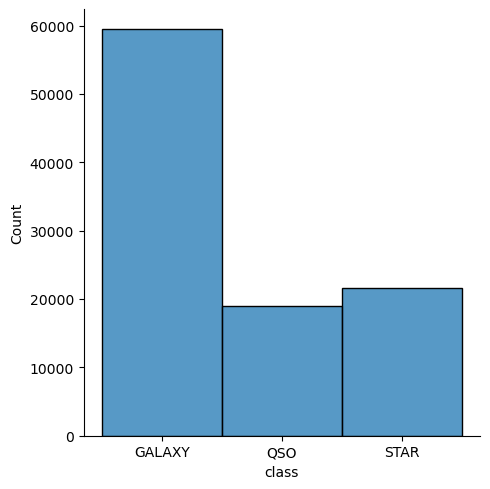

In [7]:
sns.displot(data=df, x='class')

In [8]:
from imblearn.under_sampling import RandomUnderSampler
RndUS = RandomUnderSampler(random_state=17)

X = df.drop('class', axis=1)
y = df['class']
res_X, res_y = RndUS.fit_resample(X, y)

res_df = res_X.copy()
res_df['class'] = res_y

res_df['class'].value_counts()

GALAXY    18961
QSO       18961
STAR      18961
Name: class, dtype: int64

<Axes: xlabel='class', ylabel='count'>

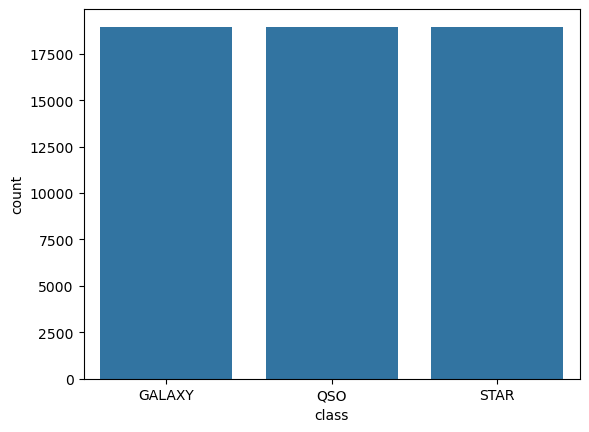

In [9]:
sns.countplot(data=res_df, x='class')

In [10]:
len(res_df)

56883

In [11]:
clipped_res_df = res_df.sample(n=27000, random_state=117)  # i made this because of limitation on the dataset size

In [12]:
clipped_res_df.shape

(27000, 18)

In [13]:
clipped_res_df['class'].value_counts()

GALAXY    9012
STAR      9000
QSO       8988
Name: class, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(clipped_res_df, test_size=0.3, random_state=17, stratify=clipped_res_df["class"])

In [15]:
train_df.head(10)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID,class
37648,1.237661e+18,131.780006,31.176427,19.36940,18.12787,17.52943,17.19604,16.95938,3606,301,4,55,1.428936e+18,0.083662,1269,52937,613,GALAXY
45515,1.237661e+18,156.737605,45.040668,21.55932,20.79034,20.13112,19.76833,19.55089,3530,301,6,256,8.318262e+18,1.514154,7388,56783,414,QSO
61179,1.237668e+18,219.297509,14.916453,22.15941,21.44747,20.71200,19.84396,20.05038,5322,301,4,64,6.159933e+18,0.810434,5471,56034,489,GALAXY
78270,1.237663e+18,239.961448,26.161812,20.95769,19.39191,18.67904,18.35519,18.12411,4002,301,4,208,2.785483e+18,-0.000261,2474,54564,24,STAR
43594,1.237655e+18,251.462479,39.158686,20.64332,19.69718,19.41441,19.37871,19.34221,2328,301,6,66,5.847047e+18,-0.000848,5193,56066,904,STAR
15883,1.237661e+18,215.544403,42.383916,18.48365,16.68731,15.86130,15.50104,15.21766,3699,301,2,169,1.570704e+18,0.075863,1395,52825,268,GALAXY
89524,1.237662e+18,176.498968,43.762328,21.42699,21.11976,20.99029,20.79965,20.65914,3813,301,1,186,9.423843e+18,0.995965,8370,57520,219,QSO
88898,1.237661e+18,226.157723,40.372066,16.54807,14.68606,13.83695,13.46843,13.17371,3699,301,6,222,1.574178e+18,0.029817,1398,53146,619,GALAXY
37257,1.237680e+18,26.912364,19.204114,21.93447,21.69373,21.12063,21.01174,20.41924,7923,301,5,351,8.587483e+18,1.567184,7627,56933,890,QSO
1799,1.237679e+18,11.961564,13.206970,22.19410,21.35137,21.38910,21.51182,21.58952,7773,301,5,388,1.243243e+19,2.517676,11042,58462,900,QSO


In [16]:
val_df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID,class
66882,1.237655e+18,131.542318,44.864176,19.57817,19.19779,19.15596,18.92438,18.97005,2243,301,2,105,7.637220e+18,0.650839,6783,56284,877,QSO
26389,1.237661e+18,211.708781,45.350733,21.65613,21.62183,20.10821,18.95115,18.43076,3699,301,6,144,6.817489e+18,0.645337,6055,56102,600,GALAXY
48094,1.237658e+18,116.409037,31.368151,18.61543,18.88776,19.30172,19.60393,19.87105,2825,301,6,63,1.158577e+19,5.454341,10290,58099,962,QSO
28207,1.237661e+18,252.584349,30.105207,21.77301,21.38107,21.30934,21.33090,21.12713,3705,301,2,349,5.847970e+18,2.083047,5194,56062,168,QSO
68671,1.237661e+18,250.024789,31.919565,22.86438,21.82349,21.49341,21.52821,20.97496,3705,301,1,331,5.856964e+18,3.130778,5202,55824,120,QSO


In [18]:
train_df.to_csv("../data/train.csv", index=False)
val_df.to_csv("../data/val.csv", index=False)